# <center><font color=navy>Data Science for Quantitative Finance</font></center>
## <center><font color=navy>Introduction to Statistical Dependence and Copulas for Finance</font> </center>
### <center> Ali Habibnia</center>

    
<center> Assistant Professor, Department of Economics, </center>
<center> and Division of Computational Modeling & Data Analytics at Virginia Tech</center>
<center> habibnia@vt.edu </center> 

### Readings:

1. ***Chapter 8***, [Financial Signal Processing and Machine Learning](https://ieeexplore.ieee.org/document/7471040) pdf file is available on Canvas

2. [Statistical Dependence: Beyond Pearson’s ρ ](https://projecteuclid.org/journals/statistical-science/volume-37/issue-1/Statistical-Dependence-Beyond-Pearsons-%CF%81/10.1214/21-STS823.full)

To many scientists and researchers, measuring dependence is synonymous with correlation and regression originated by Galton in 1888. However, in the 18th century over 100 years before Sir Francis Galton and Karl Pearson’s preoccupation with co-relation and correlation, various authors such as Thomas Bayes (in his 1763 paper) used verbal definitions of (in)dependence on occasion in their writings. 


###  $$\text{ “Anything that relies on correlation is charlatanism” (Nassim Taleb)}$$


#### Pearson’s correlation coefficient

The most common measure of correlation in stats is the Pearson Correlation. The full name is the Pearson Product Moment Correlation (PPMC). It shows the linear relationship between two sets of data. In simple terms, it answers the question, Can I draw a line graph to represent the data? Two letters are used to represent the Pearson correlation: Greek letter rho (ρ) for a population and the letter “r” for a sample.

$$r_{xy}=\frac{s_{xy}}{s_xs_y}$$

$s_{x}$ and $s_{y}$ are the sample standard deviations, and $s_{xy}$ is the sample covariance.

The explicit formula is

$$r_{xy}=\frac{n\Sigma x_iy_i-\Sigma x_i\Sigma y_i}{\sqrt{n\Sigma x_i^2-(\Sigma x_i)^2}\sqrt{n\Sigma y_i^2-(\Sigma y_i)^2})}$$



#### Limitations of the Pearson Correlation Coefficient:

1. Linearity

    a zero correlation does not necessarily imply independence of X and Y. Example: $Y = X^2$


2. Non-robustness with respect to data distribution

    only the first two moments are incorporated in the Pearson correlation coefficient and uncorrelatedness does not imply independence for some elliptical distributions or non-elliptical distributions. Pearson uncorrelatedness only implies independence if the joint distribution of the variables is normal.


3. Stationarity and Heteroskedasticity
    
    compute correlation on return series not on prices


4. Non-robustness with respect to outliers

    Pearson coefficient applies the mean as a measure for the central tendency.


5. Time frame sensitivity

    Pearson is static and Short-term correlation can be totally different from the long-term correlation. Correlations typically increase in economic recessions.


6. The correlation-causality fallacy

7. symmetric

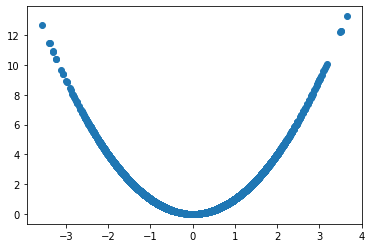

[[ 1.         -0.00952015]
 [-0.00952015  1.        ]]


In [50]:
x = pd.Series(np.random.randn(10000))
y = x**2
plt.scatter(x, y)
plt.show()
Pearson_rho = np.corrcoef(x, y)
print(Pearson_rho)

In [ ]:
!pip install yfinance

In [ ]:
!pip install missingno

In [1]:
import numpy as np
from pandas_datareader import data
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import datetime
import random
import yfinance as yf

[*********************100%***********************]  2 of 2 completed


,BTC-USD,^GSPC
Date,,
2022-03-26,44500.828125,NaN
2022-03-27,46820.492188,NaN
2022-03-28,47128.003906,4575.520020
2022-03-29,47465.730469,4631.600098
2022-03-30,47062.664062,NaN


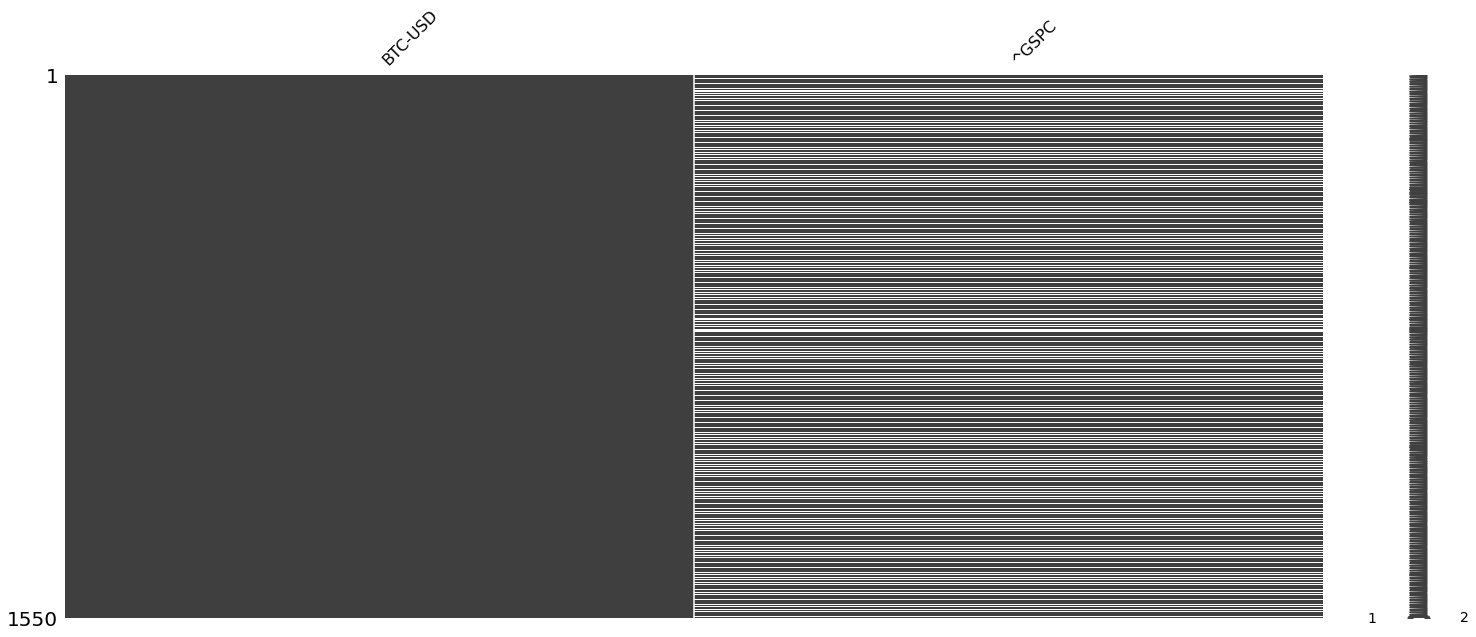

In [2]:
# Correlation and roaling correlation between S&P 500 Index and Bitcoin
sample = ['BTC-USD', '^GSPC']

Pr = yf.download(sample, start='2018-01-01', end='2022-03-30')['Adj Close']
msno.matrix(Pr)
Pr.tail()

<AxesSubplot:>

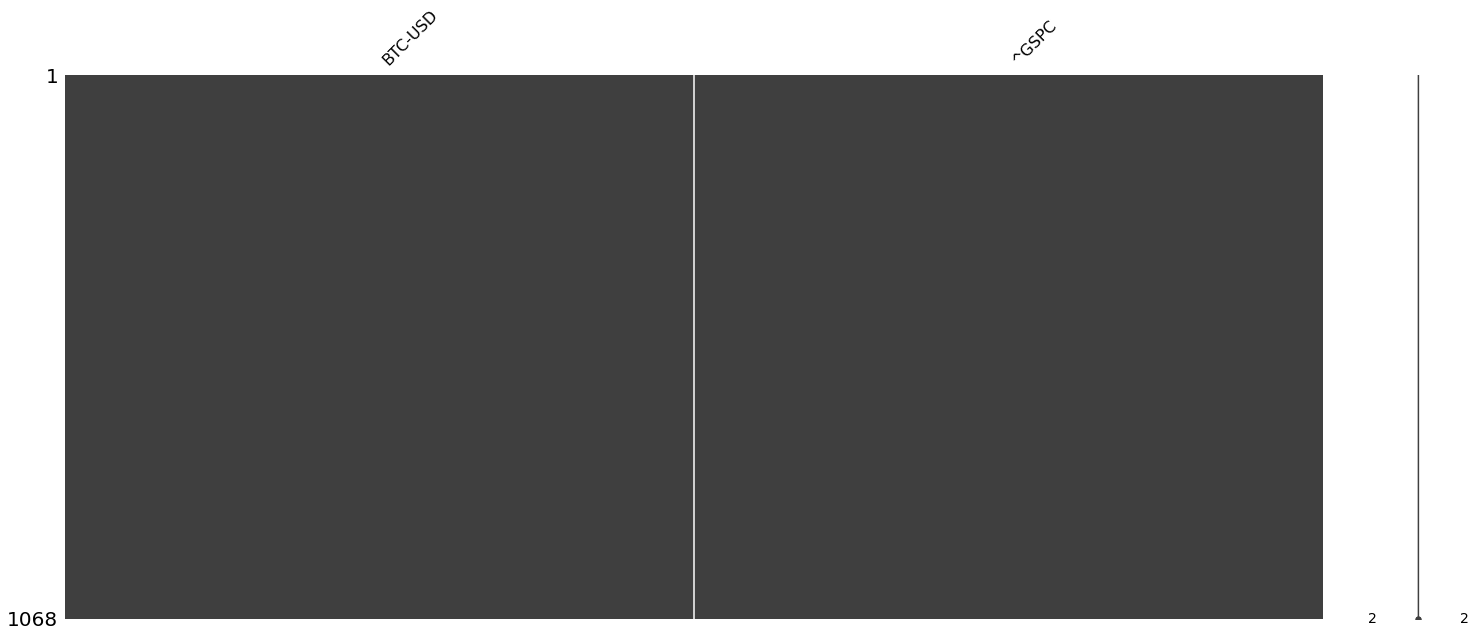

In [3]:
# Clean before calculating return values
cleaned_Pr = Pr.copy()

# Remove days (rows) with missing values for any of assets
cleaned_Pr.dropna(axis='index', how='any', inplace=True)

cleaned_Pr.tail()
msno.matrix(cleaned_Pr)

In [4]:
Re = np.log(cleaned_Pr) - np.log(cleaned_Pr.shift(1))
Re = Re[1:]
Re.tail(3)

,BTC-USD,^GSPC
Date,,
2022-03-25,0.008783,0.005053
2022-03-28,0.060783,0.007120
2022-03-29,0.007141,0.012182


<AxesSubplot:xlabel='Date'>

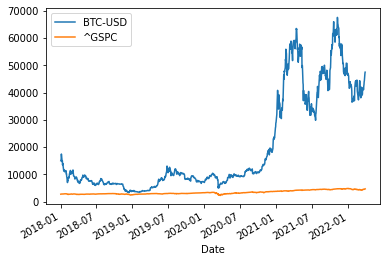

In [28]:
cleaned_Pr.plot()

<AxesSubplot:xlabel='Date'>

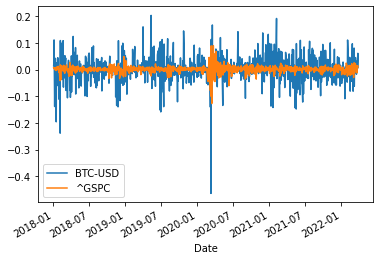

In [29]:
Re.plot()

In [53]:
# Pearson correlation for the entire data

s1 = pd.Series(Re['BTC-USD'].values)
s2 = pd.Series(Re['^GSPC'].values)
Pearson_rho = np.corrcoef(s1, s2)
print(Pearson_rho)

[[1.         0.24164016]
 [0.24164016 1.        ]]


0.16271877709550786
0.2207956763495446


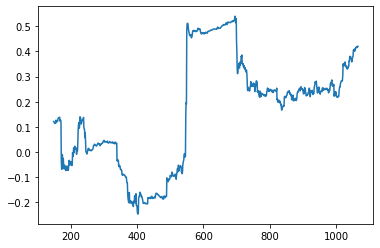

In [54]:
#Rolling correlations 

s1 = pd.Series(Re['BTC-USD'].values)
s2 = pd.Series(Re['^GSPC'].values)
n = 150
s1.rolling(n).corr(s2).plot()
print(s1.rolling(n).corr(s2).mean())
print(s1.rolling(n).corr(s2).std())

Confidence Interval:  [0.12691264 0.35713291]
Standard Error:  0.06


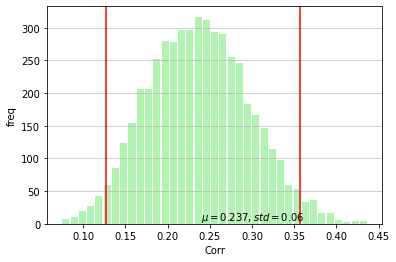

In [5]:
# Bootsrtaping (random resampling with replacement) to show the sensitivity of correlation to sample 
# and to test the significance of the correlation coefficient

Corr = []
for i in range(5000):
    data = Re.sample(n = len(Re), replace = True)
    Corr.append(data['BTC-USD'].corr(data['^GSPC'], method='pearson'))  # 'pearson' 'spearman' 'kendall'

confidence_interval = np.percentile(Corr,[2.5,97.5])
standard_error = np.round( np.std(Corr),3 )
print("Confidence Interval: ",confidence_interval)
print("Standard Error: ",standard_error)
plt.hist(x= Corr,bins='auto', color = 'lightgreen',alpha=0.7, rwidth=0.85)
plt.grid(axis='y', alpha=0.75)
plt.xlabel('Corr')
plt.ylabel('freq')
plt.text(np.round(np.mean(Corr),2), 5,r'$\mu={}, std={}$'.format(np.round( np.mean(Corr),3 ),np.round( np.std(Corr),3 ) ))
plt.axvline(x=np.percentile(Corr,[2.5]), ymin=0, ymax=1,label=confidence_interval[0],c='r')
plt.axvline(x=np.percentile(Corr,[97.5]), ymin=0, ymax=1,label=confidence_interval[1],c='r')
plt.show()

# Copulas

Copulas are powerful statistical tools for modeling and analyzing dependence structures between random variables independently from their marginal distributions. In this section, we will discuss the basic framework of copula from a mathematical perspective and explain how to apply the approach in finance with an example of stock trading.

- The word **copula** is derived from the Latin noun for a link or a tie (as is the English word “couple”), and its purpose is to describe the dependence structure between two variables.

- Consider two assets in finance. Each asset has its own distribution of returns. Copulas help us model how these assets move together—particularly useful when their relationship isn't linear or changes during extreme events.

#### Sklar’s Theorem

- Sklar's theorem forms the foundation of copula theory. It states that “Any multivariate joint distribution can be represented as a copula function $C(.)$ of its univariate marginal distributions."

- for any $d$-dimensional cumulative distribution function $F(x_1,\dots,x_d)$ with marginal distributions $F_1(x_1),\dots,F_d(x_d)$, there exists a copula $C$ such that:

$$
F(x_1,\dots,x_d) = C(F_1(x_1),\dots,F_d(x_d))
$$

> **Formally, a copula is a joint distribution function defined on uniform marginals.**
> 
> **Probability Integral Transform (PIT) is the mathematical bridge connecting marginals and copulas.**


- If marginals are continuous, then the copula is unique. Otherwise, uniqueness is not guaranteed.


- Modeling multivariate probability distributions can be difficult when the marginal probability density functions of the component random variables are different. Copulas are a useful tool for modeling dependence between random variables with any marginal distribution.

Before diving deeply into copulas, we must first understand the **Probability Integral Transform**.

#### Probability Density Function (PDF)

A probability density function $f(x)$ captures the likelihood that a random sample from the distribution is equal to $x$. For example, the probability density function for the standard normal distribution is given by

\begin{equation}
f(x) = \frac{1}{2 \pi} e^{-x^2/2}
\end{equation}

Note that the probability density function does **not** return a probability but rather a "relative likelihood" which can take on values in the interval $[0, \infty)$; however, the integral over the probability density function from $-\infty$ to $\infty$ must be equal to one.

#### Cumulative Distribution Function (CDF)

In many cases, the probability density function can be hard to work with directly. Instead, we will use the cumulative distribution function $F(x)$ which is defined as the integral of the probability density function

\begin{equation}
F(x) = \int_{-\infty}^x f(x)
\end{equation}

The below figure shows the probability density function $f(x)$ and the cumulative distribution function $F(x)$ for a normal standard distribution with mean $0.0$ and variance $1$.

In [47]:
import warnings

warnings.filterwarnings('ignore')

In [50]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

def plot_cdf_pdf():
    # Generate 10000 evenly distributed values from -4 to 4
    x = np.linspace(-4.0, 4.0, 10000)

    # Compute their Probability Densities and Cumulative Distributions
    pdf = stats.norm.pdf(x)
    cdf = stats.norm.cdf(x)

    figure = plt.figure(figsize=(16, 4))
    figure.add_subplot(1, 2, 1)
    plt.plot(x, pdf)
    plt.title("Probability Density Function")
    plt.xlabel("x")
    plt.ylabel("f(x)")

    figure.add_subplot(1, 2, 2)
    plt.plot(x, cdf)
    plt.title("Cumulative Distribution Function")
    plt.xlabel("x")
    plt.ylabel("F(x)")

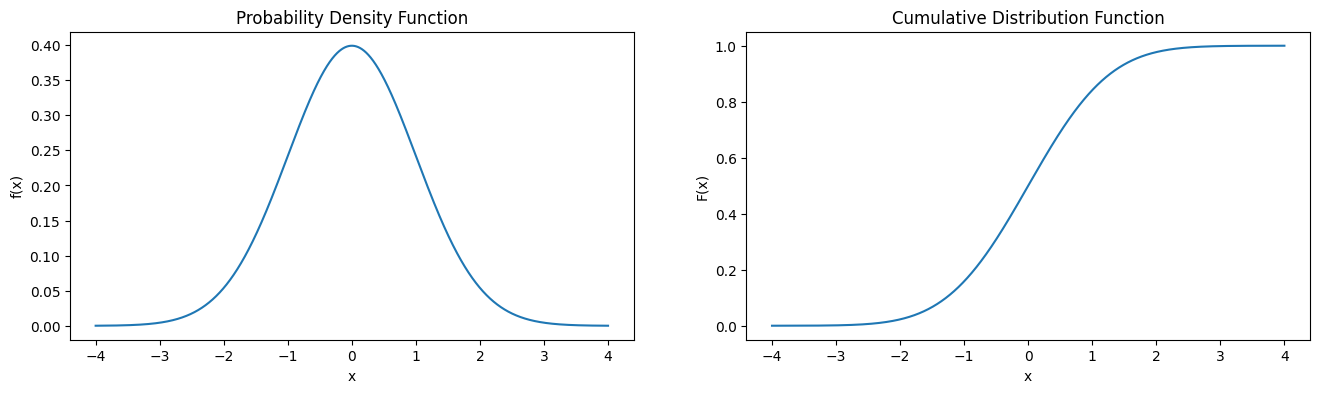

In [51]:
plot_cdf_pdf()

### Probability Integral Transform

The probability integral transform is a key component in our toolkit for working with probability distributions. Suppose $X$ is a continuous random variable with cumulative distribution function (CDF) $F_X(x)$. Then, the random variable $U=F_X(X)$ is uniformly distributed on $[0,1]$:

$$
U = F_X(X) \sim \text{Uniform}(0,1)
$$

This transformation converts any continuous random variable into a uniform variable on $[0,1]$. This step is crucial for copula theory, as copulas are defined precisely on such transformed (uniform) variables.

The figure below shows an example of this. We sample some data from a normal distribution and plot it on the left. Then, we use the CDF of the normal distribution to transform the data, plot it on the right, and observe that it resembles an uniform distribution.

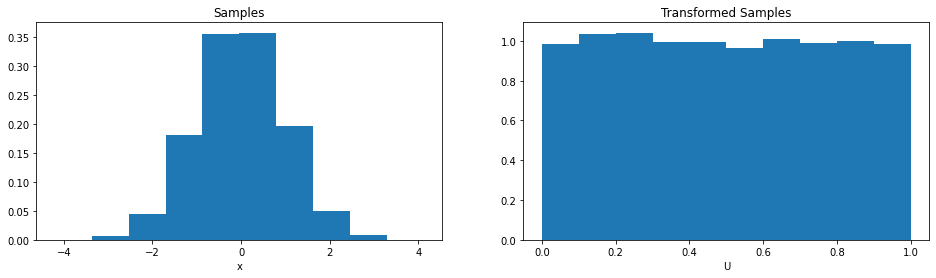

In [59]:
from scipy import stats
from matplotlib import pyplot as plt


X = stats.norm.rvs(size=10000)
X_pit = stats.norm.cdf(X)

fig = plt.figure(figsize=(16, 4))
fig.add_subplot(1, 2, 1)
plt.hist(X, density=True, bins=10)
plt.title("Samples") 
plt.xlabel("x")

fig.add_subplot(1, 2, 2)
plt.hist(X_pit, density=True, bins=10)
plt.title("Transformed Samples")
plt.xlabel("U")

plt.show()

### Definition of a Bivariate Copula using PIT

Given two random variables $X$ and $Y$ with marginals $F_X$ and $F_Y$, define new variables $U = F_X(X)$ and $V = F_Y(Y)$, both uniformly distributed on $[0,1]$.

A copula $C$ is the joint cumulative distribution function (CDF) of these uniform variables:

$$
C(u,v) = P(U\le u, V\le v), \quad u,v \in [0,1]
$$

Using Sklar’s theorem, we then reconnect this copula with our original variables:

$$
F_{X,Y}(x,y) = C(F_X(x),F_Y(y))
$$

Thus, the copula separates the dependence structure (copula $C$) from marginal behaviors ($F_X, F_Y$).

### Inverse Probability Integral Transform

After modeling dependencies in copula-space (uniform marginals), we can revert back to original marginal distributions using inverse CDFs:

$$
X = F_X^{-1}(U), \quad Y = F_Y^{-1}(V)
$$

Thus, copulas offer a flexible way of modeling dependencies, independent from marginals.


### Mathematical Definition of Multivariate Copulas

Formally, a copula is defined as a joint cumulative distribution function (CDF) whose marginals are uniform on the interval $[0,1]$.

Let us consider a random vector $(X_1, X_2, \dots, X_d)$ with marginal cumulative distribution functions (CDFs) $F_1(x_1), F_2(x_2), \dots, F_d(x_d)$. A copula is defined as a multivariate function:

$$
C: [0,1]^d \rightarrow [0,1]
$$

such that it satisfies the following properties for every $(u_1, u_2, \dots, u_d)$ in the $[0,1]^d$ hypercube:

#### 1. Groundedness (Boundary Conditions)

Copulas are grounded at zero, meaning that the copula value is zero if at least one argument is zero:

$$
C(u_1,\dots,u_{i-1},0,u_{i+1},\dots,u_d) = 0 \quad \text{for all } i \in \{1,\dots,d\}
$$

*Intuition:*  
If one random variable has an event that is certain never to occur (probability zero), the joint probability of occurrence for all variables must also be zero.


#### 2. Uniform Marginals

Each marginal of the copula is uniformly distributed on the interval $[0,1]$. Formally, for any $u_i \in [0,1]$:

$$
C(1,\dots,1,u_i,1,\dots,1) = u_i
$$

*Intuition:*  
When all other variables are known to occur with certainty (probability equal to one), the joint probability distribution reduces to the marginal probability of the remaining variable, hence the distribution is uniform.


#### 3. Monotonicity (Non-decreasing)

Copulas must be non-decreasing in each argument. Formally, given vectors $(u_1,\dots,u_d)$ and $(v_1,\dots,v_d)$ in $[0,1]^d$ with $u_i \leq v_i$ for all $i$, it follows that:

$$
C(u_1,\dots,u_d) \leq C(v_1,\dots,v_d)
$$

*Intuition:*  
If the probability of individual events increases, the joint probability of these


### Assumptions and Limitations

Copulas are based on several important assumptions:

- Marginals and copula functions are separately specified.
- Copulas assume stationarity in dependency structure.
- Marginals should ideally be continuous.

Limitations include difficulty in accurately capturing changing dependence structures, especially during financial crises.


## Common Copula Families and Their Characteristics

- **Gaussian Copula**: Captures symmetric dependence structures.
- **Student’s t-Copula**: Captures symmetric tail dependence and is useful in financial risk modeling.
- **Archimedean Copulas** (Clayton, Frank, Gumbel): Model asymmetric dependencies.

Let's visualize some common copulas.


## Example

To visualize clearly:

1. Take two random variables $X,Y$ (e.g., returns of two stocks).
2. Convert each into uniform variables $U,V$ using their CDFs.
3. Model the dependence between $U$ and $V$ using a copula (Gaussian, Clayton, etc.).
4. Use the inverse transform (inverse PIT) to go back to the original distributions, preserving the modeled dependence.

Let's demonstrate this clearly through code.


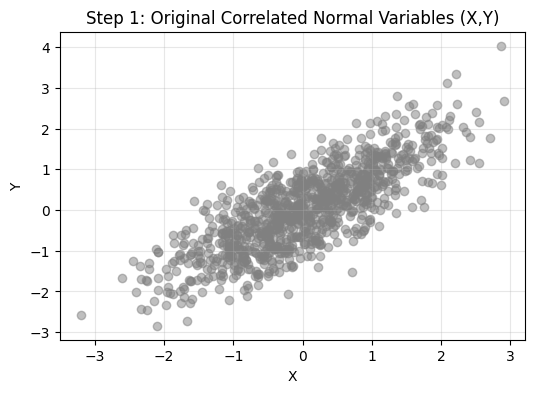

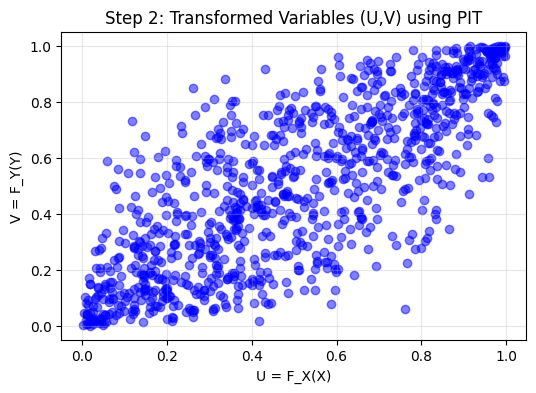

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

# Step 1: Generate correlated normal data
rho = 0.8
cov_matrix = [[1, rho], [rho, 1]]
data_normal = multivariate_normal([0, 0], cov_matrix).rvs(1000)

# Plot original correlated data (X,Y)
plt.figure(figsize=(6,4))
plt.scatter(data_normal[:,0], data_normal[:,1], alpha=0.5, color='grey')
plt.title("Step 1: Original Correlated Normal Variables (X,Y)")
plt.xlabel("X"); plt.ylabel("Y")
plt.grid(alpha=0.3)
plt.show()

# Step 2: Convert to uniform using PIT
u = norm.cdf(data_normal[:,0])
v = norm.cdf(data_normal[:,1])

# Plot transformed data (Uniform marginals)
plt.figure(figsize=(6,4))
plt.scatter(u, v, alpha=0.5, color='blue')
plt.title("Step 2: Transformed Variables (U,V) using PIT")
plt.xlabel("U = F_X(X)"); plt.ylabel("V = F_Y(Y)")
plt.grid(alpha=0.3)
plt.show()

# Step 3: Now we have a copula representation (Gaussian Copula)


### Interpretation of the Plots

- **Step 1 Plot (Original variables)**: 
We see two normally distributed variables with a clear linear correlation.

- **Step 2 Plot (Transformed variables)**: 
Applying the Probability Integral Transform, we convert each marginal distribution into uniform. The structure of dependency is preserved, but marginals are now uniform. This is the "copula space."

**What is the Copula in this context?**  
It's exactly the joint distribution you're seeing in Step 2: a joint distribution with uniform marginals. It captures the dependence without caring about original marginal shapes.


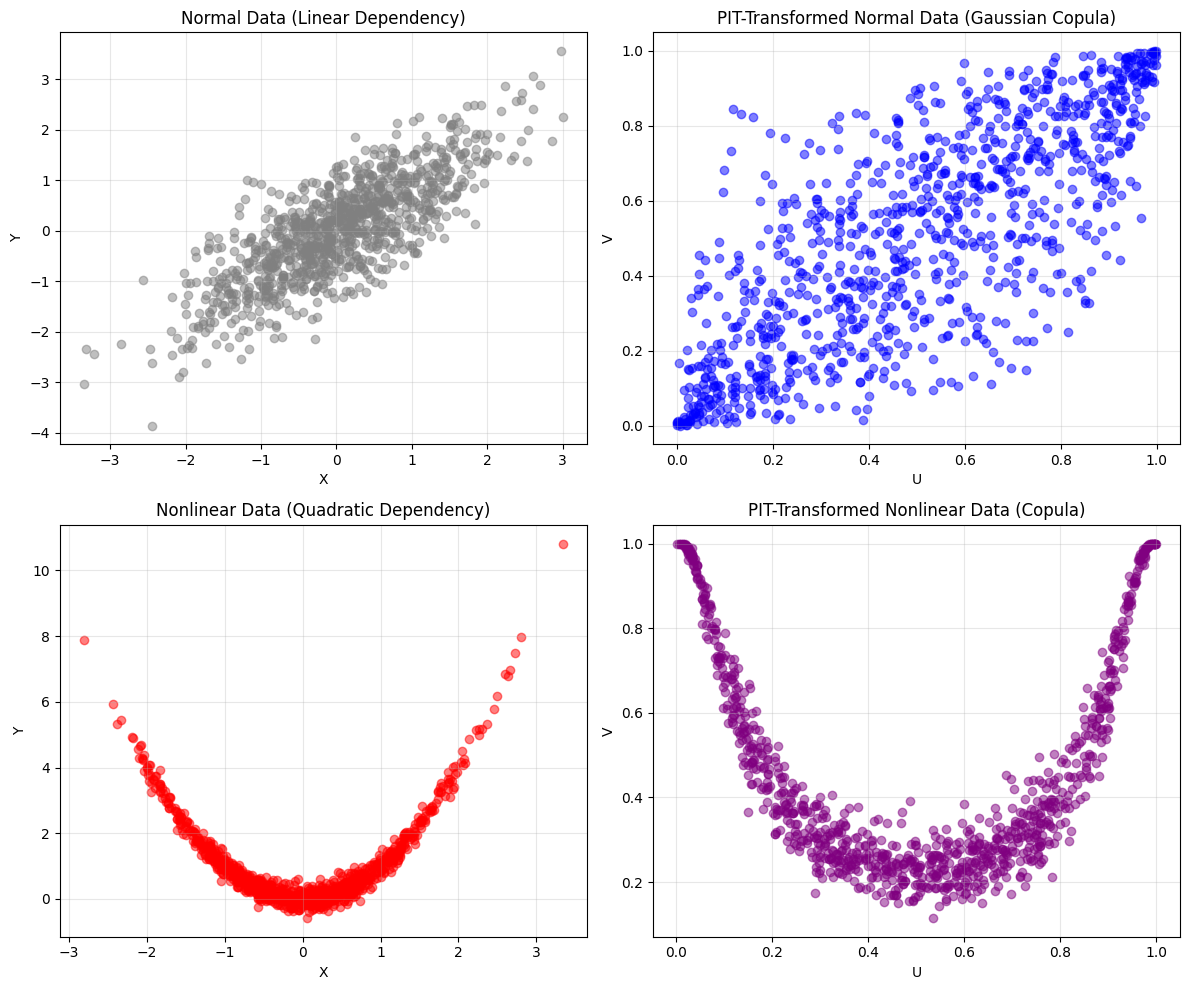

Correlation Coefficients (Linear Case):
  Pearson Correlation: 0.794
  Spearman Correlation: 0.765
  Kendall's Tau: 0.575
  Copula Spearman (PIT-space): 0.765
  Copula Kendall (PIT-space): 0.575

Correlation Coefficients (Nonlinear Case):
  Pearson Correlation: 0.034
  Spearman Correlation: -0.051
  Kendall's Tau: -0.045
  Copula Spearman (PIT-space): -0.051
  Copula Kendall (PIT-space): -0.045


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal, spearmanr, kendalltau, rankdata

# Step 1: Generate correlated normal data
rho = 0.8
cov_matrix = [[1, rho], [rho, 1]]
data_normal = multivariate_normal([0, 0], cov_matrix).rvs(1000)

# Step 2: Convert to uniform using PIT
u = norm.cdf(data_normal[:, 0])
v = norm.cdf(data_normal[:, 1])

# Compute correlation measures (Linear case)
pearson_corr = np.corrcoef(data_normal[:, 0], data_normal[:, 1])[0, 1]
spearman_corr, _ = spearmanr(data_normal[:, 0], data_normal[:, 1])
kendall_corr, _ = kendalltau(data_normal[:, 0], data_normal[:, 1])

# Step 3: Introduce a nonlinear dependency
data_nonlinear_x = np.random.normal(0, 1, 1000)
data_nonlinear_y = data_nonlinear_x ** 2 + np.random.normal(0, 0.2, 1000)

# Nonlinear correlations
nonlinear_pearson_corr = np.corrcoef(data_nonlinear_x, data_nonlinear_y)[0, 1]
nonlinear_spearman_corr, _ = spearmanr(data_nonlinear_x, data_nonlinear_y)
nonlinear_kendall_corr, _ = kendalltau(data_nonlinear_x, data_nonlinear_y)

# Nonlinear PIT
u_nonlinear = norm.cdf((data_nonlinear_x - np.mean(data_nonlinear_x)) / np.std(data_nonlinear_x))
v_nonlinear = norm.cdf((data_nonlinear_y - np.mean(data_nonlinear_y)) / np.std(data_nonlinear_y))

# Copula-based correlations (directly on PIT-transformed data)
copula_spearman_corr, _ = spearmanr(u, v)
copula_kendall_corr, _ = kendalltau(u, v)

copula_spearman_corr_nonlinear, _ = spearmanr(u_nonlinear, v_nonlinear)
copula_kendall_corr_nonlinear, _ = kendalltau(u_nonlinear, v_nonlinear)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Normal Data (linear dependency)
axs[0, 0].scatter(data_normal[:, 0], data_normal[:, 1], alpha=0.5, color='grey')
axs[0, 0].set_title("Normal Data (Linear Dependency)")
axs[0, 0].set_xlabel("X"); axs[0, 0].set_ylabel("Y"); axs[0, 0].grid(alpha=0.3)

# Normal data after PIT
axs[0, 1].scatter(u, v, alpha=0.5, color='blue')
axs[0, 1].set_title("PIT-Transformed Normal Data (Gaussian Copula)")
axs[0, 1].set_xlabel("U"); axs[0, 1].set_ylabel("V"); axs[0, 1].grid(alpha=0.3)

# Nonlinear Data
axs[1, 0].scatter(data_nonlinear_x, data_nonlinear_y, alpha=0.5, color='red')
axs[1, 0].set_title("Nonlinear Data (Quadratic Dependency)")
axs[1, 0].set_xlabel("X"); axs[1, 0].set_ylabel("Y"); axs[1, 0].grid(alpha=0.3)

# Nonlinear data after PIT
axs[1, 1].scatter(u_nonlinear, v_nonlinear, alpha=0.5, color='purple')
axs[1, 1].set_title("PIT-Transformed Nonlinear Data (Copula)")
axs[1, 1].set_xlabel("U"); axs[1, 1].set_ylabel("V"); axs[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Clearly print correlation coefficients
print("Correlation Coefficients (Linear Case):")
print(f"  Pearson Correlation: {pearson_corr:.3f}")
print(f"  Spearman Correlation: {spearman_corr:.3f}")
print(f"  Kendall's Tau: {kendall_corr:.3f}")
print(f"  Copula Spearman (PIT-space): {copula_spearman_corr:.3f}")
print(f"  Copula Kendall (PIT-space): {copula_kendall_corr:.3f}\n")

print("Correlation Coefficients (Nonlinear Case):")
print(f"  Pearson Correlation: {nonlinear_pearson_corr:.3f}")
print(f"  Spearman Correlation: {nonlinear_spearman_corr:.3f}")
print(f"  Kendall's Tau: {nonlinear_kendall_corr:.3f}")
print(f"  Copula Spearman (PIT-space): {copula_spearman_corr_nonlinear:.3f}")
print(f"  Copula Kendall (PIT-space): {copula_kendall_corr_nonlinear:.3f}")


## Why Are Copula-Based and Traditional Correlations Similar or Different?

### Linear (Normal) Case:
In the linear (Gaussian) scenario, we observe that both traditional rank correlations (**Spearman** and **Kendall**) and copula-based correlations (computed directly on PIT-transformed variables) yield very similar results. This similarity arises because:

- **Copulas derived from Gaussian distributions naturally reflect monotonic and linear dependencies**.  
- Rank-based correlations inherently measure monotonic dependency, and hence closely align with Gaussian copulas.

### Nonlinear Case (Quadratic dependency):
In the nonlinear scenario, all correlation measures—traditional and copula-based rank correlations—are very low and similar:

- **Pearson correlation** is close to zero because it strictly measures linear dependence.
- **Spearman and Kendall correlations** are also close to zero because the quadratic relation is symmetric and non-monotonic across the domain. These metrics inherently detect monotonic relationships, hence they fail here.
- **Copula-based rank correlations (Spearman/Kendall on PIT-space)** also fail to detect symmetric nonlinear dependencies for the same reason—they still rely on monotonic rankings.


# Copula in Finance

#### Copulas are widely used in finance, especially in:

- Risk Management (e.g., modeling joint defaults, VaR calculation)
- Portfolio Management (capturing asset dependencies beyond linear correlation)
- Derivatives Pricing (pricing complex instruments dependent on multiple underlying assets)

#### Why is this Useful in Finance?

- Financial assets rarely have linear dependencies.
- Copulas capture nonlinear dependencies, especially during market stress.
- Risk models (Value at Risk, Expected Shortfall) benefit significantly by accurately modeling joint tail risks.

Next, let's simulate a simple financial scenario using copulas clearly.


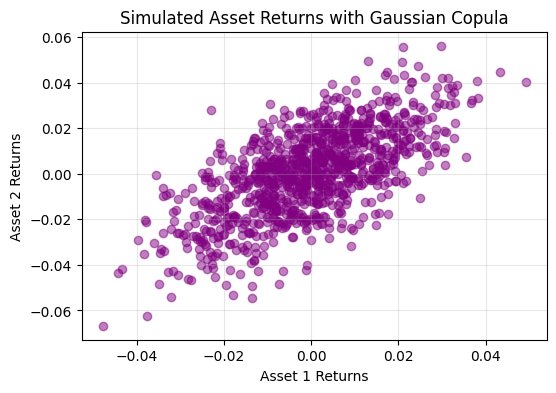

In [9]:
# Parameters for two financial assets
rho = 0.7
cov_matrix_finance = [[1, rho], [rho, 1]]

# Generate Gaussian copula data
copula_data = multivariate_normal([0, 0], cov_matrix_finance).rvs(1000)
u_finance, v_finance = norm.cdf(copula_data[:,0]), norm.cdf(copula_data[:,1])

# Convert to realistic asset returns (inverse transform with specific marginals)
asset1_returns = norm.ppf(u_finance, loc=0.001, scale=0.015)
asset2_returns = norm.ppf(v_finance, loc=0.0015, scale=0.02)

# Plot simulated asset returns
plt.figure(figsize=(6,4))
plt.scatter(asset1_returns, asset2_returns, alpha=0.5, color='purple')
plt.title("Simulated Asset Returns with Gaussian Copula")
plt.xlabel("Asset 1 Returns"); plt.ylabel("Asset 2 Returns")
plt.grid(alpha=0.3)
plt.show()


### Copula Modeling of Financial Data using Student's t-Copula

Model the joint dependency structure between financial assets using a **Student's t Copula**, which captures **tail dependencies** that standard correlation cannot.

We will:
- Download real financial time series data.
- Compute log returns and apply the **Probability Integral Transform (PIT)**.
- Fit a Student's t Copula.
- Simulate synthetic dependent data.
- Visualize and interpret the tail dependency captured by the copula.

Let's begin.


[*********************100%***********************]  3 of 3 completed


Fitted Student t-Copula Parameters
Degrees of Freedom: 3.4181194704149966
Correlation Matrix (ρ):
 [[1.         0.71293058 0.78015934]
 [0.71293058 1.         0.79835386]
 [0.78015934 0.79835386 1.        ]]


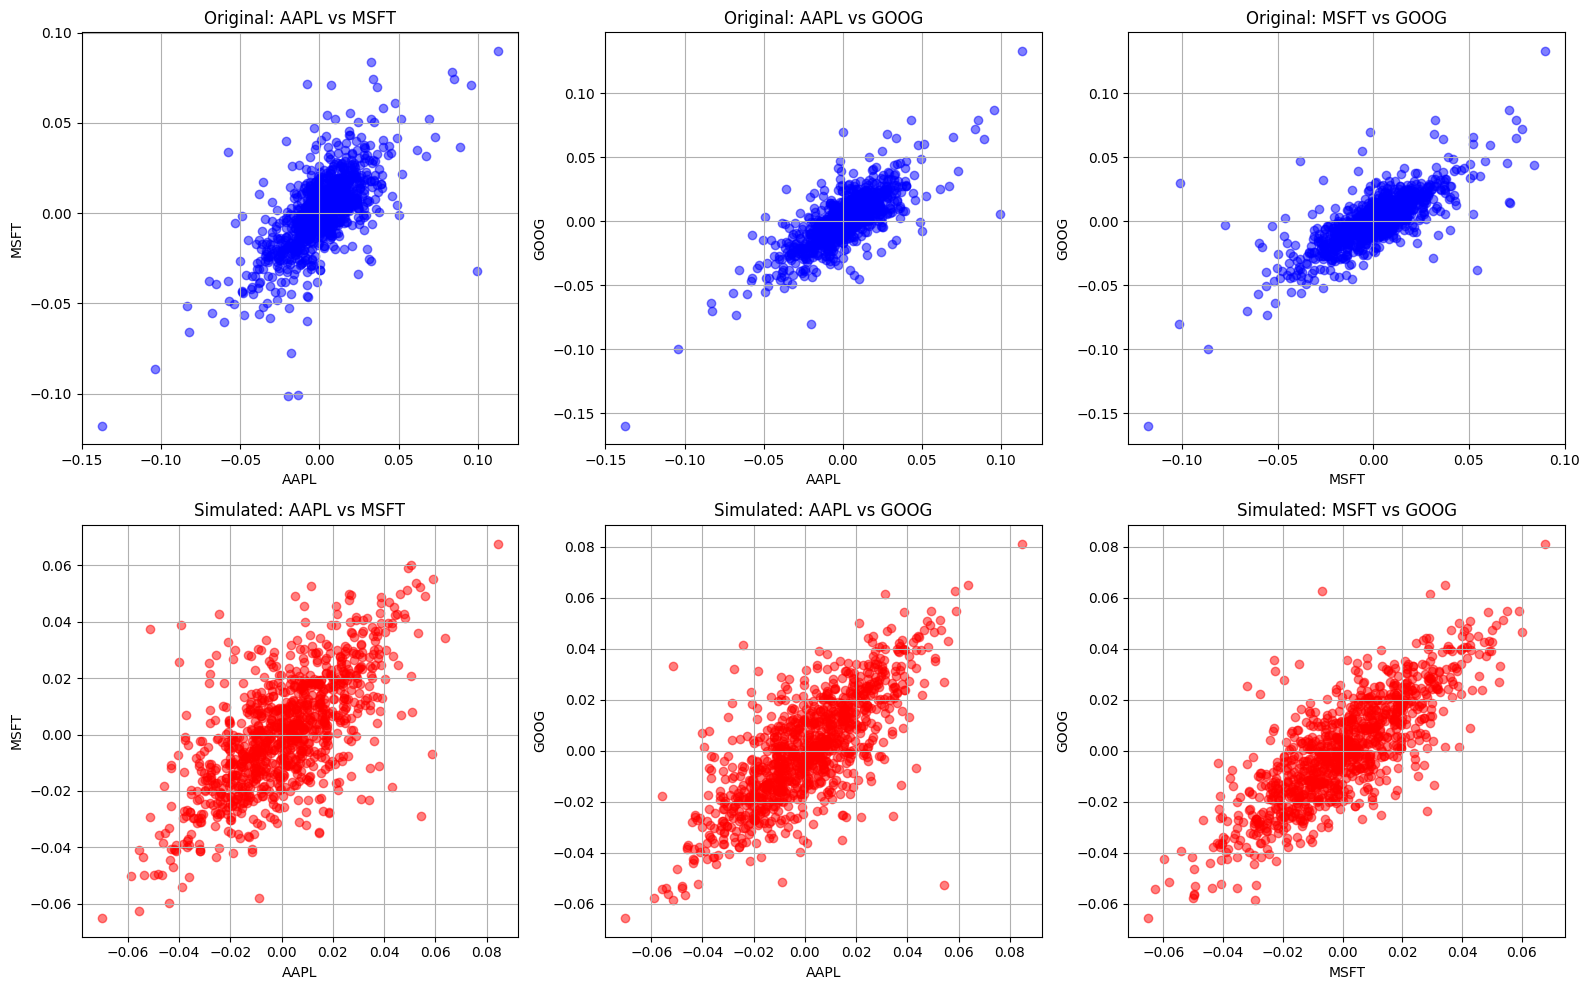


 Approximate Tail Dependence Coefficients (λ_L = λ_U for t-Copula):
AAPL ~ MSFT: λ ≈ 0.4337
AAPL ~ GOOG: λ ≈ 0.4974
MSFT ~ AAPL: λ ≈ 0.4337
MSFT ~ GOOG: λ ≈ 0.5169
GOOG ~ AAPL: λ ≈ 0.4974
GOOG ~ MSFT: λ ≈ 0.5169


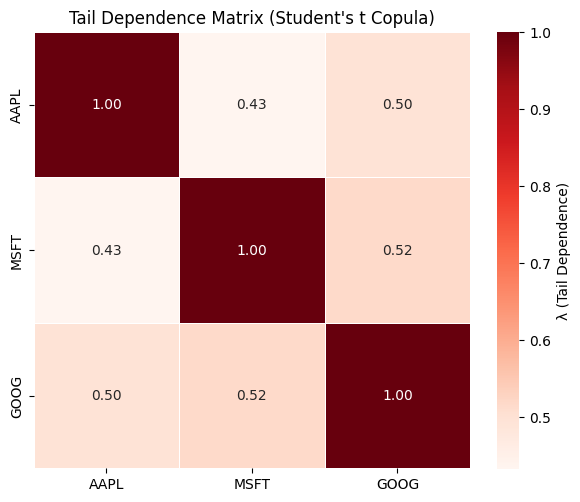

In [52]:
import yfinance as yf
import numpy as np
import pandas as pd
from scipy.stats import norm, t
from copulae import StudentCopula
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Download Close prices
tickers = ['AAPL', 'MSFT', 'GOOG']
data = yf.download(tickers, start='2020-01-01', end='2024-01-01')['Close']
data.dropna(inplace=True)

# Step 2: Compute log returns
log_returns = np.log(data / data.shift(1)).dropna()

# Step 3: Standardize and apply PIT
scaler = StandardScaler()
z_returns = pd.DataFrame(scaler.fit_transform(log_returns), index=log_returns.index, columns=tickers)
uniform_data = pd.DataFrame(norm.cdf(z_returns), index=z_returns.index, columns=tickers)
uniform_data_clipped = uniform_data.clip(1e-6, 1 - 1e-6)

# Step 4: Fit Student Copula
copula = StudentCopula(dim=len(tickers))
copula.fit(uniform_data_clipped.values, method="ml")

# Step 5: Extract and reshape parameters
params = copula.params
df = float(params[0])             # Degrees of freedom
flat_rho = np.array(params[1])    # Flattened lower triangle of correlation matrix

# Reconstruct correlation matrix
dim = len(tickers)
rho = np.eye(dim)
k = 0
for i in range(dim):
    for j in range(i):
        rho[i, j] = rho[j, i] = flat_rho[k]
        k += 1

print("Fitted Student t-Copula Parameters")
print("Degrees of Freedom:", df)
print("Correlation Matrix (ρ):\n", rho)

# Step 6: Simulate copula data
sim_uv = copula.random(1000)
sim_uv = np.clip(sim_uv, 1e-6, 1 - 1e-6)

# Step 7: Inverse transform to simulated returns
simulated_returns = pd.DataFrame(index=range(1000), columns=tickers)
for i, ticker in enumerate(tickers):
    mu = log_returns[ticker].mean()
    sigma = log_returns[ticker].std()
    simulated_returns[ticker] = norm.ppf(sim_uv[:, i], loc=mu, scale=sigma)

# Step 8: Scatter Plots
pairs = [(0, 1), (0, 2), (1, 2)]
fig, axs = plt.subplots(2, 3, figsize=(16, 10))

for k, (i, j) in enumerate(pairs):
    axs[0, k].scatter(log_returns.iloc[:, i], log_returns.iloc[:, j], alpha=0.5, color='blue')
    axs[0, k].set_title(f"Original: {tickers[i]} vs {tickers[j]}")
    axs[0, k].set_xlabel(tickers[i]); axs[0, k].set_ylabel(tickers[j])
    axs[0, k].grid(True)

    axs[1, k].scatter(simulated_returns.iloc[:, i], simulated_returns.iloc[:, j], alpha=0.5, color='red')
    axs[1, k].set_title(f"Simulated: {tickers[i]} vs {tickers[j]}")
    axs[1, k].set_xlabel(tickers[i]); axs[1, k].set_ylabel(tickers[j])
    axs[1, k].grid(True)

plt.tight_layout()
plt.show()

# Step 9: Tail Dependence Matrix + Heatmap
print("\n Approximate Tail Dependence Coefficients (λ_L = λ_U for t-Copula):")
tail_matrix = np.zeros((dim, dim))

for i in range(dim):
    for j in range(dim):
        if i == j:
            tail_matrix[i, j] = 1.0  # perfect self-dependence
        else:
            corr = rho[i, j]
            tail_dep = 2 * t.cdf(-np.sqrt((df + 1) * (1 - corr) / (1 + corr)), df + 1)
            tail_matrix[i, j] = tail_dep
            print(f"{tickers[i]} ~ {tickers[j]}: λ ≈ {tail_dep:.4f}")

# Create DataFrame and plot heatmap
tail_df = pd.DataFrame(tail_matrix, index=tickers, columns=tickers)

plt.figure(figsize=(6, 5))
sns.heatmap(tail_df, annot=True, fmt=".2f", cmap="Reds", square=True, linewidths=0.5, cbar_kws={"label": "λ (Tail Dependence)"})
plt.title("Tail Dependence Matrix (Student's t Copula)")
plt.tight_layout()
plt.show()


> There is a ~43% chance that if AAPL returns hit an extreme, MSFT will also hit an extreme (in the same direction).

## Trading Strategy based on Copula

In this section, we investigate using copula theory to identify trading opportunities. 

Stander Y, Marais D, Botha I. Trading strategies with copulas. Journal of Economic and Financial Sciences, 2013, 6(1): 83-107. https://journals.co.za/doi/pdf/10.10520/EJC135921

Typically the asset price distribution is modeled by a  Gaussian distribution of return series but the joint normal distribution may fail to catch some key features of the dependence of stock pairs' price like tail dependence. 

To determine which stock pairs to include in the analysis, correlations between pairs are analyzed using daily log stock price returns.  

- The Pearson correlation assumes that both variables should be normally distributed. Thus here we use Kendall rank as the correlation measure to choose the pairs.

In order to construct the copula, we need to transform the log-return series R1 and R2 to two uniformly distributed values U1 and U2. This can be done by estimating the marginal distribution functions of Rx
R1 and R2 and plugging the return values into a distribution function. As we make no assumptions about the distribution of the two log-return series, here we use the empirical distribution function to approach the marginal distribution F1(R1) and F2(R2). The Python ECDF function from the statsmodel library gives us the Empirical CDF as a step function.

Then, we estimate the copula parameter (i.e. theta for Archimedean copulas) by the relationship between the copula and the dependence measure Kendall’s tau.

The copula functions include all the information about the dependence structures of two return series. In Trading strategies with copulas, the fitted copula is used to derive the confidence bands for the conditional marginal distribution function of C(U1∣U2) and C(U2∣U1), that is the mispricing indexes. When the market observations fall outside the confidence band, it is an indication that pairs trading opportunity is available. 

Please also see "Copula for Pairs Trading: A Detailed, But Practical Introduction" for more details. 
https://hudsonthames.org/copula-for-pairs-trading-introduction/

For python code see: https://www.quantconnect.com/tutorials/strategy-library/pairs-trading-copula-vs-cointegration

## The Gaussian Copula and the Financial Crisis

In fact, Gaussian copulas are said to have played a key role in the 2007-2008 Financial Crisis as tail-correlations were severely underestimated. If you've seen The Big Short, the default rates of individual mortgages (among other things) inside CDOs are correlated -- if one mortgage fails, the likelihood of another failing is increased. In the early 2000s, the banks only knew how to model the marginals of the default rates. But we could  use copulas to model the correlations between those marginals. Rating agencies relied on this model heavily, severly underestimating risk and giving false ratings. 

Read this paper http://samueldwatts.com/wp-content/uploads/2016/08/Watts-Gaussian-Copula_Financial_Crisis.pdf for a description of Gaussian copulas and the Financial Crisis which argues that different copula choices would not have made a difference but instead the assumed correlation was way too low.